In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.DataFrame({'Co2': [344.58, 346.04, 347.39, 349.16, 351.56, 353.07, 354.35, 355.57, 356.38, 357.07, 358.82, 360.8, 362.59, 363.71, 366.65, 368.33, 369.52, 371.13, 373.22, 375.77, 377.49, 379.8, 381.9, 383.76, 385.59, 387.37, 389.85, 391.63, 393.82, 396.48, 398.61],
                   'Temp': [0.27, 0.234, 0.414, 0.666, 0.666, 0.522, 0.774, 0.72, 0.45, 0.504, 0.612, 0.81, 0.576, 0.918, 1.134, 0.792, 0.756, 0.972, 1.08, 1.098, 1.026, 1.17, 1.098, 1.098, 0.972, 1.134, 1.26, 1.026, 1.116, 1.188, 1.332 ]})

In [ ]:
df.head()

,Co2,Temp
0,344.58,0.270
1,346.04,0.234
2,347.39,0.414
3,349.16,0.666
4,351.56,0.666


In [ ]:
import statsmodels.api as sm

#define predictor and response variables
y = df['Co2']
x = df['Temp']

#add constant to predictor variables
x = sm.add_constant(x)

#fit linear regression model
model = sm.OLS(y, x).fit()

#view model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    Co2   R-squared:                       0.785
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     106.2
Date:                Sun, 12 Feb 2023   Prob (F-statistic):           3.32e-11
Time:                        13:11:59   Log-Likelihood:                -106.06
No. Observations:                  31   AIC:                             216.1
Df Residuals:                      29   BIC:                             219.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        328.6297      4.190     78.426      0.0

/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


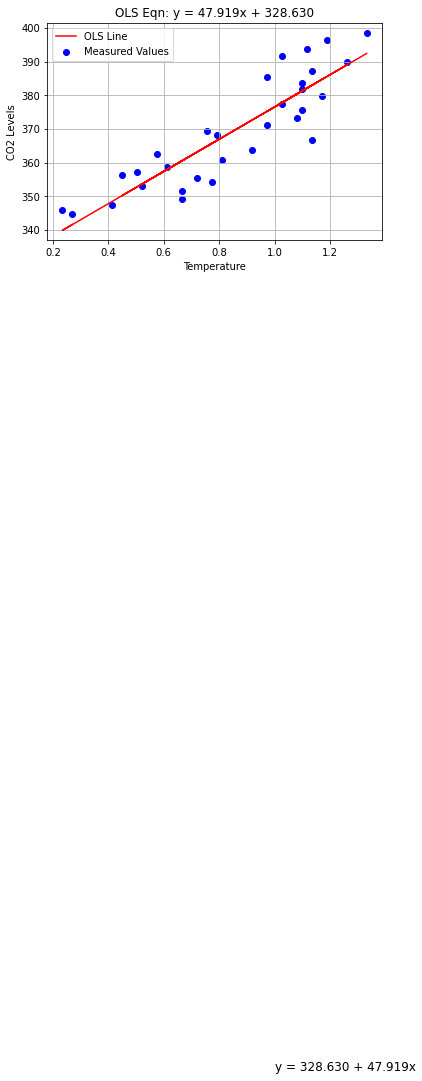

In [ ]:
import matplotlib.pyplot as plt

#find line of best fit
a, b = np.polyfit(df['Temp'], df['Co2'], 1)

#add points to plot
plt.scatter(df['Temp'], df['Co2'], color='b')

#add line of best fit to plot
plt.plot(df['Temp'], a*df['Temp']+b, color='r')

#add fitted regression equation to plot
plt.text(1, 90, 'y = ' + '{:.3f}'.format(b) + ' + {:.3f}'.format(a) + 'x', size=12)

plt.style.use('tableau-colorblind10')
plt.grid()
plt.xlabel('Temperature')
plt.ylabel('CO2 Levels')
plt.title('OLS Eqn: y = 47.919x + 328.630')


plt.legend(['OLS Line','Measured Values'])

#add axis labels

In [ ]:
from scipy.odr import *
import random

In [ ]:
x=df['Temp']
y=df['Co2']

In [ ]:
# Define a function (quadratic in our case) to fit the data with.
def linear_func(p, x):
   m, c = p
   return m*x + c

# Create a model for fitting.
linear_model = Model(linear_func)

# Create a RealData object using our initiated data from above.
data = RealData(x, y)

# Set up ODR with the model and data.
odr = ODR(data, linear_model, beta0=[0., 1.])

# Run the regression.
out = odr.run()

# Use the in-built pprint method to give us results.
out.pprint()

Beta: [ 61.00010173 317.494818  ]
Beta Std Error: [5.918896   5.27185326]
Beta Covariance: [[ 1746.93769045 -1487.03843316]
 [-1487.03843316  1385.87041361]]
Residual Variance: 0.02005413817821797
Inverse Condition #: 0.024728901569467564
Reason(s) for Halting:
  Sum of squares convergence


In [ ]:
length=len(df)
length

31

In [ ]:
covariance=0
for i in range(length) :
  covariance += (x[i] - x.mean())*(y[i] - y.mean())

covariance = covariance/length
covariance

4.192155234131115

In [ ]:
# syy -> y.var()
# suu -> x.var()
# syu -> Covariance 4.19

In [ ]:
# X -> Temp
X=np.array([0.27, 0.234, 0.414, 0.666, 0.666, 0.522, 0.774, 0.72, 0.45, 0.504, 0.612, 0.81, 0.576, 0.918, 1.134, 0.792, 0.756, 0.972, 1.08, 1.098, 1.026, 1.17, 1.098, 1.098, 0.972, 1.134, 1.26, 1.026, 1.116, 1.188, 1.332])
suu=X.var()
suu

0.08748404578563997

In [ ]:
Y=np.array([344.58, 346.04, 347.39, 349.16, 351.56, 353.07, 354.35, 355.57, 356.38, 357.07, 358.82, 360.8, 362.59, 363.71, 366.65, 368.33, 369.52, 371.13, 373.22, 375.77, 377.49, 379.8, 381.9, 383.76, 385.59, 387.37, 389.85, 391.63, 393.82, 396.48, 398.61])
syy=Y.var()
syy

255.7407257023934

In [ ]:
syu=covariance

In [ ]:
import math

In [ ]:
Alpha = (syy - suu + math.sqrt(pow((syy-suu),2)+4*pow(syu,2)))/(2*syu)
Alpha

61.00011833950697

In [ ]:
Beta = Y.mean() - Alpha*X.mean()
Beta

317.49480249216424

In [ ]:
y=Alpha*x+Beta
y

0     333.964834
1     331.768830
2     342.748851
3     358.120881
4     358.120881
5     349.336864
6     364.708894
7     361.414888
8     344.944856
9     348.238862
10    354.826875
11    366.904898
12    352.630871
13    373.492911
14    386.668937
15    365.806896
16    363.610892
17    376.786918
18    383.374930
19    384.472932
20    380.080924
21    388.864941
22    384.472932
23    384.472932
24    376.786918
25    386.668937
26    394.354952
27    380.080924
28    385.570935
29    389.962943
30    398.746960
Name: Temp, dtype: float64

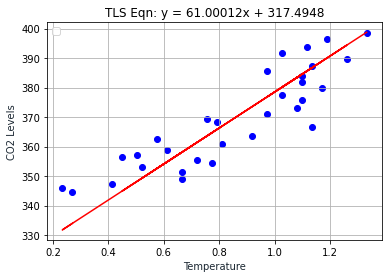

In [ ]:
plt.plot(x, y, '-r')
plt.scatter(df['Temp'],df['Co2'], color='b')
plt.title('Graph')
plt.xlabel('x', color='#1C2833')
plt.ylabel('y', color='#1C2833')
plt.legend(loc='upper left')

plt.style.use('tableau-colorblind10')
plt.xlabel('Temperature')
plt.ylabel('CO2 Levels')
plt.title('TLS Eqn: y = 61.00012x + 317.4948')

plt.grid()
plt.show()

In [ ]:
import pandas as pd

data_file_path = 'defects.csv'

data = pd.read_csv(data_file_path) 

data.head()

,Defect 1,Unnamed: 1,Unnamed: 2,Defect 2,Unnamed: 4,Unnamed: 5,Defect 3,Unnamed: 7
0,x,y,NaN,x,y,NaN,x,y
1,3557,826,NaN,2183,3241,NaN,2931,3706
2,3557,809,NaN,2177,3235,NaN,2930,3693
3,3565,812,NaN,2172,3234,NaN,2928,3691
4,3591,816,NaN,2166,3229,NaN,2927,3685


In [ ]:
len(data)

120

In [ ]:
df1=data.loc[0:,['Defect 1','Unnamed: 1']]
df1

,Defect 1,Unnamed: 1
0,x,y
1,3557,826
2,3557,809
3,3565,812
4,3591,816
...,...,...
115,NaN,NaN
116,NaN,NaN
117,NaN,NaN
118,NaN,NaN


In [ ]:
df2=data.loc[0:,['Defect 2','Unnamed: 4']]
df2

,Defect 2,Unnamed: 4
0,x,y
1,2183,3241
2,2177,3235
3,2172,3234
4,2166,3229
...,...,...
115,NaN,NaN
116,NaN,NaN
117,NaN,NaN
118,NaN,NaN


In [ ]:
df3=data.loc[0:,['Defect 3','Unnamed: 7']]
df3

,Defect 1,Unnamed: 1
0,x,y
1,3557,826
2,3557,809
3,3565,812
4,3591,816
...,...,...
115,NaN,NaN
116,NaN,NaN
117,NaN,NaN
118,NaN,NaN


In [ ]:
df1.dropna(inplace=True)
df2.dropna(inplace=True)
df3.dropna(inplace=True)
print(len(df1))
print(len(df2))
print(len(df3))

46
35
120


In [ ]:
df1

,Defect 1,Unnamed: 1
0,x,y
1,3557,826
2,3557,809
3,3565,812
4,3591,816
5,3607,816
6,3613,814
7,3624,815
8,3630,813
9,3659,815


In [ ]:
df2

,Defect 2,Unnamed: 4
0,x,y
1,2183,3241
2,2177,3235
3,2172,3234
4,2166,3229
5,2162,3228
6,2157,3223
7,2153,3222
8,2139,3211
9,2135,3210


In [ ]:
df3

,Defect 3,Unnamed: 7
0,x,y
1,2931,3706
2,2930,3693
3,2928,3691
4,2927,3685
...,...,...
115,2943,3714
116,2936,3724
117,2934,3730
118,2930,3721


In [ ]:
df1.drop(0,inplace=True)
df2.drop(0,inplace=True)
df3.drop(0,inplace=True)
print(len(df1))
print(len(df2))
print(len(df3))

45
34
119


In [ ]:
df1.reset_index(inplace = True)
df2.reset_index(inplace = True)
df3.reset_index(inplace = True)

In [ ]:
df1 = df1.astype(float)
df2 = df2.astype(float)
df3 = df3.astype(float)

In [ ]:
type(df1['Unnamed: 1'][0])

numpy.float64

In [ ]:
x1=df1['Defect 1']
y1=df1['Unnamed: 1']
length1=len(df1)
#length1
covariance1=0
for i in range(len(df1)) :
  covariance1 += (x1[i] - x1.mean())*(y1[i] - y1.mean())

covariance1 = covariance1/length1
#covariance1

X1=np.array(df1['Defect 1'])
suu1=X1.var()
#suu1
Y1=np.array(df1['Unnamed: 1'])
syy1=Y1.var()
#syy1
syu1=covariance1

Alpha1 = (syy1 - suu1 + math.sqrt(pow((syy1-suu1),2)+4*pow(syu1,2)))/(2*syu1)
#Alpha
Beta1 = Y1.mean() - Alpha1*X1.mean()
#Beta

In [ ]:
print(Alpha1)
print(Beta1)

0.009293594658007148
788.964635524005


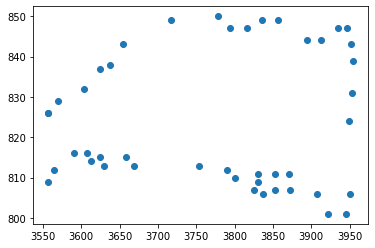

In [ ]:
plt.scatter(x1,y1)

In [ ]:
y1=Alpha1*x1+Beta1
y1

0     822.021952
1     822.021952
2     822.096300
3     822.337934
4     822.486631
5     822.542393
6     822.644623
7     822.700384
8     822.969898
9     823.062834
10    823.843496
11    824.187359
12    824.289589
13    824.568397
14    824.568397
15    824.512635
16    824.624158
17    824.772856
18    824.772856
19    824.940140
20    824.949434
21    825.284003
22    825.414114
23    825.627866
24    825.674334
25    825.665041
26    825.702215
27    825.711509
28    825.692922
29    825.646454
30    825.534931
31    825.330471
32    825.163187
33    824.810030
34    824.614865
35    824.428993
36    824.224534
37    824.085130
38    823.508927
39    822.923430
40    822.774733
41    822.644623
42    822.458751
43    822.142768
44    822.021952
Name: Defect 1, dtype: float64

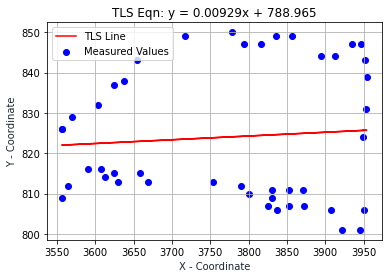

In [ ]:
plt.plot(x1, y1, '-r')
plt.scatter(df1['Defect 1'],df1['Unnamed: 1'],color='b')
plt.title('Graph')
plt.xlabel('x', color='#1C2833')
plt.ylabel('y', color='#1C2833')

plt.style.use('tableau-colorblind10')
plt.xlabel('X - Coordinate')
plt.ylabel('Y - Coordinate')
plt.title('TLS Eqn: y = 0.00929x + 788.965')

plt.legend(['TLS Line','Measured Values'],loc='best')
plt.grid()
plt.show()

In [ ]:
x2=df2['Defect 2']
y2=df2['Unnamed: 4']
length2=len(df2)
#length2
covariance2=0
for i in range(len(df2)) :
  covariance2 += (x2[i] - x2.mean())*(y2[i] - y2.mean())

covariance2 = covariance2/length2
#covariance2

X2=np.array(df2['Defect 2'])
suu2=X2.var()
#suu2
Y2=np.array(df2['Unnamed: 4'])
syy2=Y2.var()
#syy2
syu2=covariance2

Alpha2 = (syy2 - suu2 + math.sqrt(pow((syy2-suu2),2)+4*pow(syu2,2)))/(2*syu2)
#Alpha2
Beta2 = Y2.mean() - Alpha2*X2.mean()
#Beta2

In [ ]:
print(Alpha2)
print(Beta2)

0.9295003595288812
1197.4370527417877


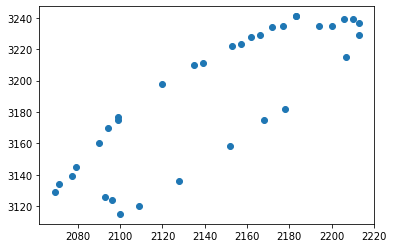

In [ ]:
plt.scatter(x2,y2)

In [ ]:
y2=Alpha2*x2+Beta2
y2

0     3226.536338
1     3220.959335
2     3216.311834
3     3210.734831
4     3207.016830
5     3202.369328
6     3198.651327
7     3185.638322
8     3181.920320
9     3167.977815
10    3148.458307
11    3148.458307
12    3143.810806
13    3140.092804
14    3129.868300
15    3128.009299
16    3122.432297
17    3120.573297
18    3142.881305
19    3145.669806
20    3149.387808
21    3157.753311
22    3175.413818
23    3197.721826
24    3212.593832
25    3221.888836
26    3248.844346
27    3254.421348
28    3254.421348
29    3251.632847
30    3247.914846
31    3242.337844
32    3236.760842
33    3226.536338
Name: Defect 2, dtype: float64

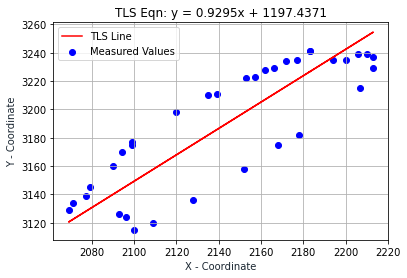

In [ ]:
plt.plot(x2, y2, '-r')
plt.scatter(df2['Defect 2'],df2['Unnamed: 4'],color='b')
plt.title('Graph')
plt.xlabel('x', color='#1C2833')
plt.ylabel('y', color='#1C2833')
plt.legend(loc='upper left')

plt.style.use('tableau-colorblind10')
plt.xlabel('X - Coordinate')
plt.ylabel('Y - Coordinate')
plt.title('TLS Eqn: y = 0.9295x + 1197.4371')

plt.legend(['TLS Line','Measured Values'],loc='upper left')

plt.grid()
plt.show()

In [ ]:
x3=df3['Defect 3']
y3=df3['Unnamed: 7']
length3=len(df3)
#length3
covariance3=0
for i in range(len(df3)) :
  covariance3 += (x3[i] - x3.mean())*(y3[i] - y3.mean())

covariance3 = covariance3/length3
#covariance3

X3=np.array(df3['Defect 3'])
suu3=X3.var()
#suu3
Y3=np.array(df3['Unnamed: 7'])
syy3=Y3.var()
#syy3
syu3=covariance3

Alpha3 = (syy3 - suu3 + math.sqrt(pow((syy3-suu3),2)+4*pow(syu3,2)))/(2*syu3)
#Alpha3
Beta3 = Y3.mean() - Alpha3*X3.mean()
#Beta3

In [ ]:
print(Alpha3)
print(Beta3)

28.429820450623527
-77012.2032306205


In [ ]:
y3=Alpha3*x3+Beta3
y3

0      6315.600510
1      6287.170690
2      6230.311049
3      6201.881228
4      6116.591767
          ...     
114    6656.758356
115    6457.749612
116    6400.889972
117    6287.170690
118    6315.600510
Name: Defect 3, Length: 119, dtype: float64

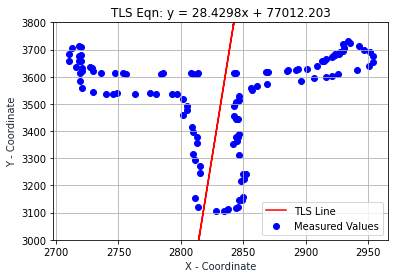

In [ ]:
plt.plot(x3, y3, '-r')
plt.scatter(df3['Defect 3'],df3['Unnamed: 7'],color='b')
plt.title('Graph')
plt.xlabel('x', color='#1C2833')
plt.ylabel('y', color='#1C2833')

plt.style.use('tableau-colorblind10')
plt.xlabel('X - Coordinate')
plt.ylabel('Y - Coordinate')
plt.title('TLS Eqn: y = 28.4298x + 77012.203')

plt.legend(['TLS Line','Measured Values'],loc='lower right')


plt.grid()
plt.ylim(3000,3800)
plt.show()

In [ ]:
df=pd.DataFrame({'Year': [1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014],
                 'Co2': [344.58, 346.04, 347.39, 349.16, 351.56, 353.07, 354.35, 355.57, 356.38, 357.07, 358.82, 360.8, 362.59, 363.71, 366.65, 368.33, 369.52, 371.13, 373.22, 375.77, 377.49, 379.8, 381.9, 383.76, 385.59, 387.37, 389.85, 391.63, 393.82, 396.48, 398.61],
                   'Temp': [0.27, 0.234, 0.414, 0.666, 0.666, 0.522, 0.774, 0.72, 0.45, 0.504, 0.612, 0.81, 0.576, 0.918, 1.134, 0.792, 0.756, 0.972, 1.08, 1.098, 1.026, 1.17, 1.098, 1.098, 0.972, 1.134, 1.26, 1.026, 1.116, 1.188, 1.332 ]})

x=np.asmatrix(df['Co2'])
y=np.asmatrix(df['Year'])
x.reshape(1,-1)
y.reshape(1,-1)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x,y)
y_pred=model.predict(np.asmatrix(df['Year']).reshape(1,-1))
y_pred

/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/utils/validation.py:593: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(


array([[1984., 1985., 1986., 1987., 1988., 1989., 1990., 1991., 1992.,
        1993., 1994., 1995., 1996., 1997., 1998., 1999., 2000., 2001.,
        2002., 2003., 2004., 2005., 2006., 2007., 2008., 2009., 2010.,
        2011., 2012., 2013., 2014.]])

In [ ]:
y.shape

(31,)

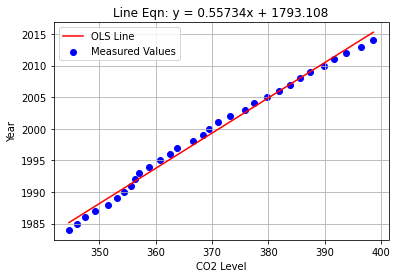

In [ ]:
X = df['Co2'].values[:,np.newaxis]
# target data is array of shape (n,) 
y = df['Year'].values


model2 = LinearRegression()
model2.fit(X, y)
plt.style.use('tableau-colorblind10')
plt.grid()
plt.xlabel('CO2 Level')
plt.ylabel('Year')
plt.title('Line Eqn: y = 0.55734x + 1793.108')
plt.scatter(X, y,color='b')
plt.plot(X, model2.predict(X),color='r')
plt.legend(['OLS Line','Measured Values'],loc='upper left')
plt.show()

In [ ]:
print(model2.intercept_)
print(model2.coef_)

1793.10813175236
[0.55733866]
